<div style="text-align:center;">

# 🚢 Titanic - Machine Learning From Disaster
## 📊 Exploratory Data Analysis (EDA)


</div>

In [17]:
# Import required libraries for data analysis
import pandas as pd
import numpy as np
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import seaborn as sns
# Display success message
display(HTML("""
<div style="
    background-color:#d4edda;
    color:#155724;
    border:2px solid #c3e6cb;
    border-radius:10px;
    padding:15px;
    font-size:18px;
    font-weight:bold;
    text-align:center;">
    ✅ Required libraries imported successfully!
</div>
"""))

In [11]:
# Upload dataset from your computer
from google.colab import files
# Display upload instruction
display(HTML("""
<div style="
    background-color:#e8f4fd;
    color:#0c5460;
    border-left:6px solid #17a2b8;
    border-radius:8px;
    padding:15px;
    font-size:16px;">
    <h3 style="margin-top:0;">📂 Upload Titanic Dataset</h3>
    Please select the required dataset file(s) from your computer.
</div>
"""))
# Open upload dialog
uploaded = files.upload()
# Display success message
display(HTML(f"""
<div style="
    background-color:#d4edda;
    color:#155724;
    border-left:6px solid #28a745;
    border-radius:8px;
    padding:15px;
    font-size:16px;">
    ✅ <b>Upload Successful!</b><br>
    Uploaded file(s): <b>{', '.join(uploaded.keys())}</b>
</div>
"""))

Saving train.csv to train (1).csv


In [10]:
# Load Titanic training dataset
df = pd.read_csv("train.csv")
# Display success message
display(HTML("""
<div style="
    background-color:#d4edda;
    color:#155724;
    border:2px solid #c3e6cb;
    border-radius:10px;
    padding:15px;
    font-size:18px;
    font-weight:bold;
    text-align:center;">
    ✅ Titanic dataset loaded successfully!
</div>
"""))

In [ ]:
# Display first five records of dataset
display(HTML(
    "<h2 style='color:#1f77b4;'>📌 First Five Rows of Dataset</h2>"
))
df.head().style.background_gradient(cmap="Blues")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.250000,nan,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.000000,1,0,PC 17599,71.283300,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.925000,nan,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.100000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.050000,nan,S


In [ ]:
# Display last five records
display(HTML(
    "<h2 style='color:#1f77b4;'>📌 Last Five Rows of Dataset</h2>"
))
df.tail().style.background_gradient(cmap="Greens")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.000000,nan,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.000000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,nan,1,2,W./C. 6607,23.450000,nan,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.000000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.000000,0,0,370376,7.750000,nan,Q


In [7]:
display(HTML("""
<h2 style="color:#1f77b4;">📌 Dataset Information</h2>
"""))
# Dataset overview
display(HTML(f"""
<div style="
background-color:#e8f4fd;
padding:12px;
border-radius:8px;
font-size:16px;
line-height:1.8;">
<b>Total Rows:</b> {df.shape[0]}<br>
<b>Total Columns:</b> {df.shape[1]}<br>
<b>Memory Usage:</b> {df.memory_usage(deep=True).sum()/1024:.2f} KB
</div>
"""))
# Column information
info_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null Count": df.count().values
})
display(
    info_df.style
    .set_properties(**{
        "text-align": "center",
        "padding": "8px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1f77b4"),
                ("color", "white"),
                ("text-align", "center")
            ]
        }
    ])
)
# Count of each data type
display(HTML("""
<h3 style="color:#1f77b4;">📌 Data Type Summary</h3>
"""))
dtype_summary = (
    df.dtypes.astype(str)
      .value_counts()
      .reset_index()
)
dtype_summary.columns = ["Data Type", "Number of Columns"]

display(
    dtype_summary.style
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1f77b4"),
                ("color", "white"),
                ("text-align", "center")
            ]
        }
    ])
)

,Column,Data Type,Non-Null Count
0,PassengerId,int64,891
1,Survived,int64,891
2,Pclass,int64,891
3,Name,object,891
4,Sex,object,891
5,Age,float64,714
6,SibSp,int64,891
7,Parch,int64,891
8,Ticket,object,891
9,Fare,float64,891


,Data Type,Number of Columns
0,int64,5
1,object,5
2,float64,2


In [ ]:
# Generate statistical summary of numerical columns
display(HTML(
    "<h2 style='color:#1f77b4;'>📌 Statistical Summary</h2>"
))
df.describe().style.background_gradient(cmap="Blues")

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Create dataset shape table
shape_df = pd.DataFrame({
    "Metric": ["Total Rows", "Total Columns"],
    "Value": [df.shape[0], df.shape[1]]
})
# Title
display(HTML(
    """
    <h2 style="
    color:#1f77b4;
    font-family:Arial;">
    📌 Dataset Shape
    </h2>
    """
))
# Styled table
display(
    shape_df.style
    .set_properties(**{
        'text-align': 'center',
        'font-size': '16px',
        'padding': '10px'
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', '#1f77b4'),
                ('color', 'white'),
                ('font-size', '16px'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('border', '1px solid #dddddd'),
                ('text-align', 'center')
            ]
        }
    ])
)

,Metric,Value
0,Total Rows,891
1,Total Columns,12


In [ ]:
# Check missing values in every column
display(HTML(
    "<h2 style='color:#d62728;'>📌 Missing Values</h2>"
))
missing_df = pd.DataFrame({
    "Missing Values":df.isnull().sum()
})
missing_df.style.background_gradient(cmap="Reds")

,Missing Values
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Calculate missing values percentage
display(HTML(
    "<h2 style='color:#d62728;'>📌 Missing Value Percentage</h2>"
))
missing_percentage = pd.DataFrame({
    "Missing Values":df.isnull().sum(),
    "Percentage (%)":round(df.isnull().mean()*100,2)
})
missing_percentage.style.background_gradient(cmap="Reds")

,Missing Values,Percentage (%)
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.870000
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


In [ ]:
# Identify numerical columns
display(HTML(
    "<h2 style='color:#1f77b4;'>📌 Numerical Columns</h2>"
))
numerical = pd.DataFrame({
    "Numerical Columns":
    df.select_dtypes(include=np.number).columns
})
numerical.style.background_gradient(cmap="Blues")

,Numerical Columns
0,PassengerId
1,Survived
2,Pclass
3,Age
4,SibSp
5,Parch
6,Fare


In [ ]:
# Identify categorical columns
display(HTML(
    "<h2 style='color:#1f77b4;'>📌 Categorical Columns</h2>"
))
categorical = pd.DataFrame({
    "Categorical Columns":
    df.select_dtypes(include="object").columns
})
categorical.style.background_gradient(cmap="Greens")

,Categorical Columns
0,Name
1,Sex
2,Ticket
3,Cabin
4,Embarked


In [ ]:
# Check duplicate records
display(HTML(
    """
    <h2 style='color:#1f77b4;'>
    📌 Duplicate Rows Analysis
    </h2>
    """
))
duplicate_count = df.duplicated().sum()
if duplicate_count == 0:
    display(HTML(
        """
        <div style="
        background-color:#d4edda;
        padding:15px;
        border-radius:10px;
        color:#155724;
        font-size:18px;">
        ✅ No duplicate rows found in the dataset
        </div>
        """
    ))
else:
    display(HTML(
        f"""
        <div style="
        background-color:#f8d7da;
        padding:15px;
        border-radius:10px;
        color:#721c24;
        font-size:18px;">
        ⚠️ Duplicate rows found: <b>{duplicate_count}</b>
        </div>
        """
    ))

In [ ]:
# Count unique values in each column
display(HTML(
    "<h2 style='color:#1f77b4;'>📌 Unique Values</h2>"
))
unique_df = pd.DataFrame({
    "Column":df.columns,
    "Unique Values":df.nunique()
})
unique_df.style.background_gradient(cmap="Purples")

,Column,Unique Values
PassengerId,PassengerId,891
Survived,Survived,2
Pclass,Pclass,3
Name,Name,891
Sex,Sex,2
Age,Age,88
SibSp,SibSp,7
Parch,Parch,7
Ticket,Ticket,681
Fare,Fare,248


In [ ]:
# Analyze target variable Survived
display(HTML(
    "<h2 style='color:#1f77b4;'>📌 Survival Distribution</h2>"
))
survival = df["Survived"].value_counts()

survival_df = pd.DataFrame({
    "Survived":survival.index,
    "Count":survival.values
})
survival_df.style.background_gradient(cmap="Blues")

,Survived,Count
0,0,549
1,1,342


In [ ]:
# Rank columns according to missing values
display(HTML(
    "<h2 style='color:#d62728;'>📌 Missing Value Ranking</h2>"
))
missing_rank = df.isnull().sum().sort_values(ascending=False)
missing_rank_df = pd.DataFrame({
    "Column":missing_rank.index,
    "Missing Values":missing_rank.values
})
missing_rank_df.style.background_gradient(cmap="Reds")

,Column,Missing Values
0,Cabin,687
1,Age,177
2,Embarked,2
3,PassengerId,0
4,Name,0
5,Pclass,0
6,Survived,0
7,Sex,0
8,Parch,0
9,SibSp,0


In [ ]:
# Find numerical feature relationship with Survived
display(HTML(
    """
    <h2 style='color:#1f77b4;'>
    📌 Correlation With Survival
    </h2>
    """
))
# Calculate correlation values
correlation = (
    df.corr(numeric_only=True)["Survived"]
    .sort_values(ascending=False)
)
# Convert to dataframe
correlation_df = pd.DataFrame({
    "Feature": correlation.index,
    "Correlation": correlation.values.round(3)
})
# Display formatted table
display(
    correlation_df.style
    .set_properties(**{
        "text-align": "center",
        "font-size": "15px"
    })
    .background_gradient(
        cmap="coolwarm",
        subset=["Correlation"]
    )
)

,Feature,Correlation
0,Survived,1.000000
1,Fare,0.257000
2,Parch,0.082000
3,PassengerId,-0.005000
4,SibSp,-0.035000
5,Age,-0.077000
6,Pclass,-0.338000


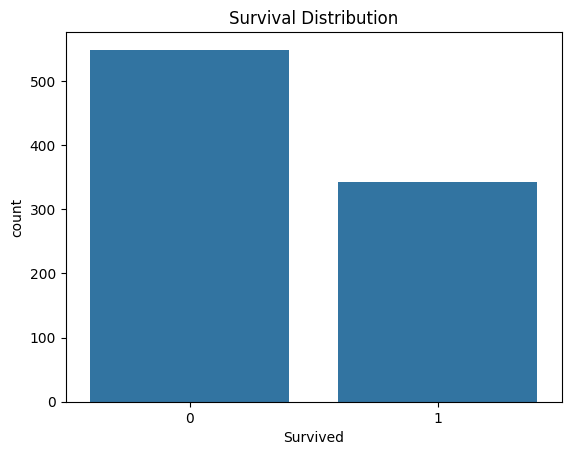

In [18]:
sns.countplot(data=df, x="Survived")
plt.title("Survival Distribution")
plt.show()

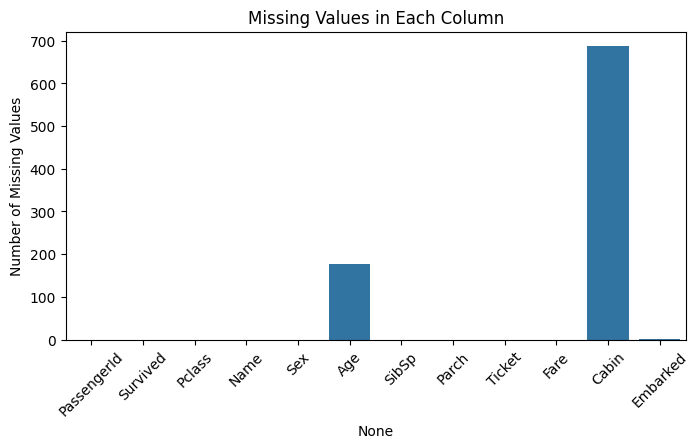

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(
    x=df.isnull().sum().index,
    y=df.isnull().sum().values
)
plt.xticks(rotation=45)
plt.title("Missing Values in Each Column")
plt.ylabel("Number of Missing Values")
plt.show()

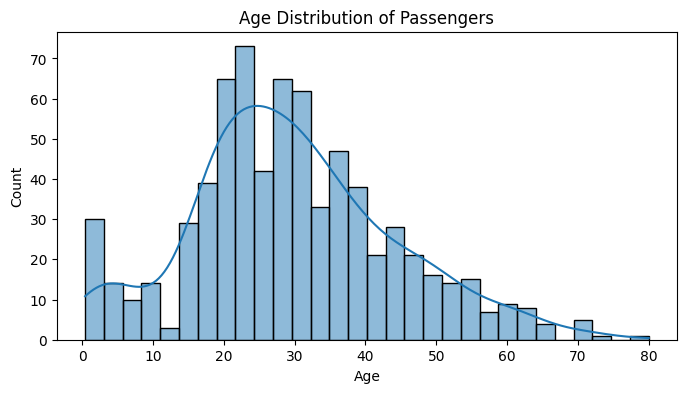

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.show()

In [14]:
# Age Distribution Summary by Gender
male_age = df[df["Sex"] == "male"]["Age"]
female_age = df[df["Sex"] == "female"]["Age"]
display(HTML(f"""
<div style="
background-color:#e8f4fd;
padding:15px;
border-radius:10px;
border-left:6px solid #1f77b4;
font-size:16px;
line-height:1.6;">
<h3 style="color:#1f77b4;">📊 Age Distribution Summary</h3>
<ul>
    <li><b>Total Passengers with Age Data:</b> {df['Age'].count()}</li>
    <li><b>Overall Average Age:</b> {df['Age'].mean():.2f} years</li>
    <li><b>Median Age:</b> {df['Age'].median():.2f} years</li>
    <li><b>Youngest Passenger:</b> {df['Age'].min():.2f} years</li>
    <li><b>Oldest Passenger:</b> {df['Age'].max():.2f} years</li>
</ul>
<h4 style="color:#1f77b4;">👨 Male Passengers</h4>
<ul>
    <li><b>Number with Age Data:</b> {male_age.count()}</li>
    <li><b>Average Age:</b> {male_age.mean():.2f} years</li>
    <li><b>Median Age:</b> {male_age.median():.2f} years</li>
</ul>
<h4 style="color:#1f77b4;">👩 Female Passengers</h4>
<ul>
    <li><b>Number with Age Data:</b> {female_age.count()}</li>
    <li><b>Average Age:</b> {female_age.mean():.2f} years</li>
    <li><b>Median Age:</b> {female_age.median():.2f} years</li>
</ul>
</div>
"""))

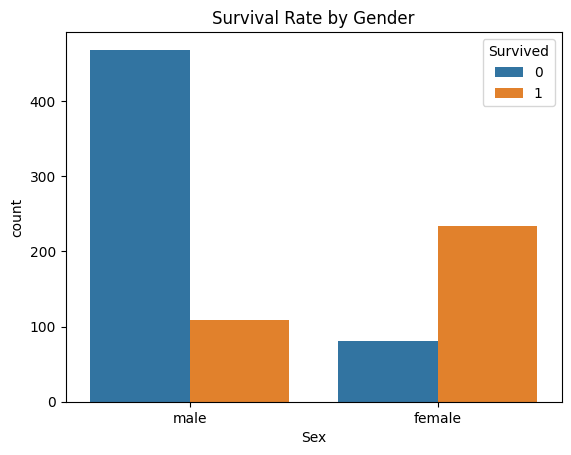

In [ ]:
sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)
plt.title("Survival Rate by Gender")
plt.show()

In [16]:
# Survival distribution by gender summary
gender_summary = df.groupby("Sex")["Survived"].agg(
    Total_Passengers="count",
    Survivors="sum",
    Survival_Rate="mean"
)
male_survival = gender_summary.loc["male"]
female_survival = gender_summary.loc["female"]
display(HTML(f"""
<div style="
background-color:#e8f4fd;
padding:15px;
border-radius:10px;
border-left:6px solid #1f77b4;
font-size:16px;
line-height:1.8;">
<h3 style="color:#1f77b4;">👥 Survival Distribution by Gender</h3>
<h4>👨 Male Passengers</h4>
<ul>
    <li><b>Total Passengers:</b> {male_survival['Total_Passengers']}</li>
    <li><b>Survived:</b> {male_survival['Survivors']}</li>
    <li><b>Survival Rate:</b> {male_survival['Survival_Rate']*100:.2f}%</li>
</ul>
<h4>👩 Female Passengers</h4>
<ul>
    <li><b>Total Passengers:</b> {female_survival['Total_Passengers']}</li>
    <li><b>Survived:</b> {female_survival['Survivors']}</li>
    <li><b>Survival Rate:</b> {female_survival['Survival_Rate']*100:.2f}%</li>
</ul>
</div>
"""))

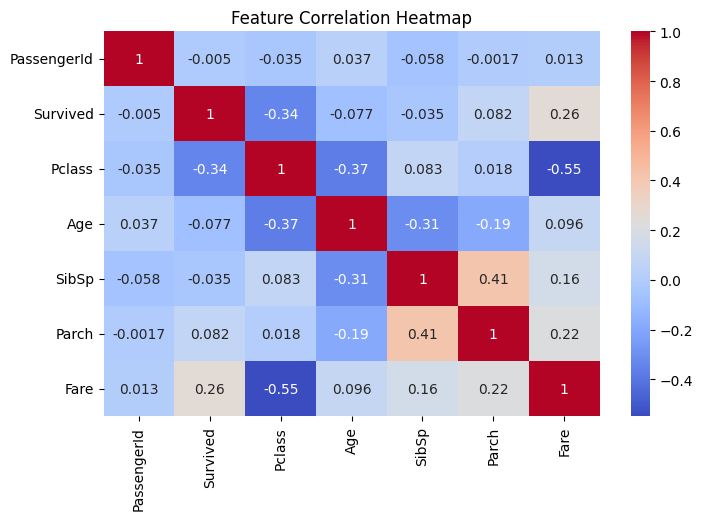

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Heatmap")
plt.show()

# 📊 Data Story: Titanic Dataset Exploratory Analysis

The Titanic dataset contains **891 passenger records and 12 features**, including passenger demographics, ticket information, family details, and survival status. The dataset consists of both **numerical features** (Age, Fare, Pclass, SibSp, Parch) and **categorical features** (Sex, Embarked, Ticket, Cabin).

The initial inspection using `head()`, `info()`, and `describe()` showed that the dataset contains a mixture of data types and requires preprocessing before machine learning. Missing value analysis revealed that **Cabin has the highest number of missing values, followed by Age and Embarked**, which indicates the need for suitable missing-value handling techniques.

The dataset contains **no duplicate records**, and feature analysis showed different levels of uniqueness among columns. The survival distribution graph showed that the number of passengers who did not survive was higher than those who survived, indicating an imbalanced target variable.

The visual analysis revealed important survival patterns. The gender-based survival graph showed that **female passengers had a higher survival rate compared to male passengers**. The passenger class analysis indicated that **first-class passengers had better survival chances compared to lower classes**. The age distribution graph helped understand the passenger age range and demographic patterns.

The correlation analysis showed relationships between numerical features and survival. Features such as **Passenger Class and Fare showed noticeable relationships with survival**, helping identify potentially important features for machine learning models.

Overall, this EDA provided a clear understanding of the dataset structure, data quality issues, feature behavior, and survival patterns. These findings will guide the next steps of data preprocessing, feature engineering, and machine learning model development.